<a href="https://colab.research.google.com/github/kyungeunvoyage/NailFoldExp/blob/main/Analysis/(Analysis)Force_Discrimination.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 스타일 설정
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

#x 축에 페어가 오는 전체 코드 (isCorrect 재배열)



발견된 파일: ['P53_ForceDiscrimination.csv', 'P23_ForceDiscrimination.csv', 'P42_ForceDiscrimination.csv', 'P50_ForceDiscrimination.csv', 'P47_ForceDiscrimination.csv', 'P56_ForceDiscrimination.csv', 'P27_ForceDiscrimination.csv', 'P21_ForceDiscrimination.csv', 'P49_ForceDiscrimination.csv', 'P46_ForceDiscrimination.csv', 'P44_ForceDiscrimination.csv', 'P24_ForceDiscrimination.csv', 'P30_ForceDiscrimination.csv', 'P25_ForceDiscrimination.csv', 'P22_ForceDiscrimination.csv', 'P52_ForceDiscrimination.csv', 'P26_ForceDiscrimination.csv', 'P48_ForceDiscrimination.csv', 'P60_ForceDiscrimination.csv', 'P51_ForceDiscrimination.csv', 'P32_ForceDiscrimination.csv', 'P59_ForceDiscrimination.csv', 'P54_ForceDiscrimination.csv', 'P28_ForceDiscrimination.csv', 'P45_ForceDiscrimination.csv', 'P55_ForceDiscrimination.csv']
Number of Subjects: 26


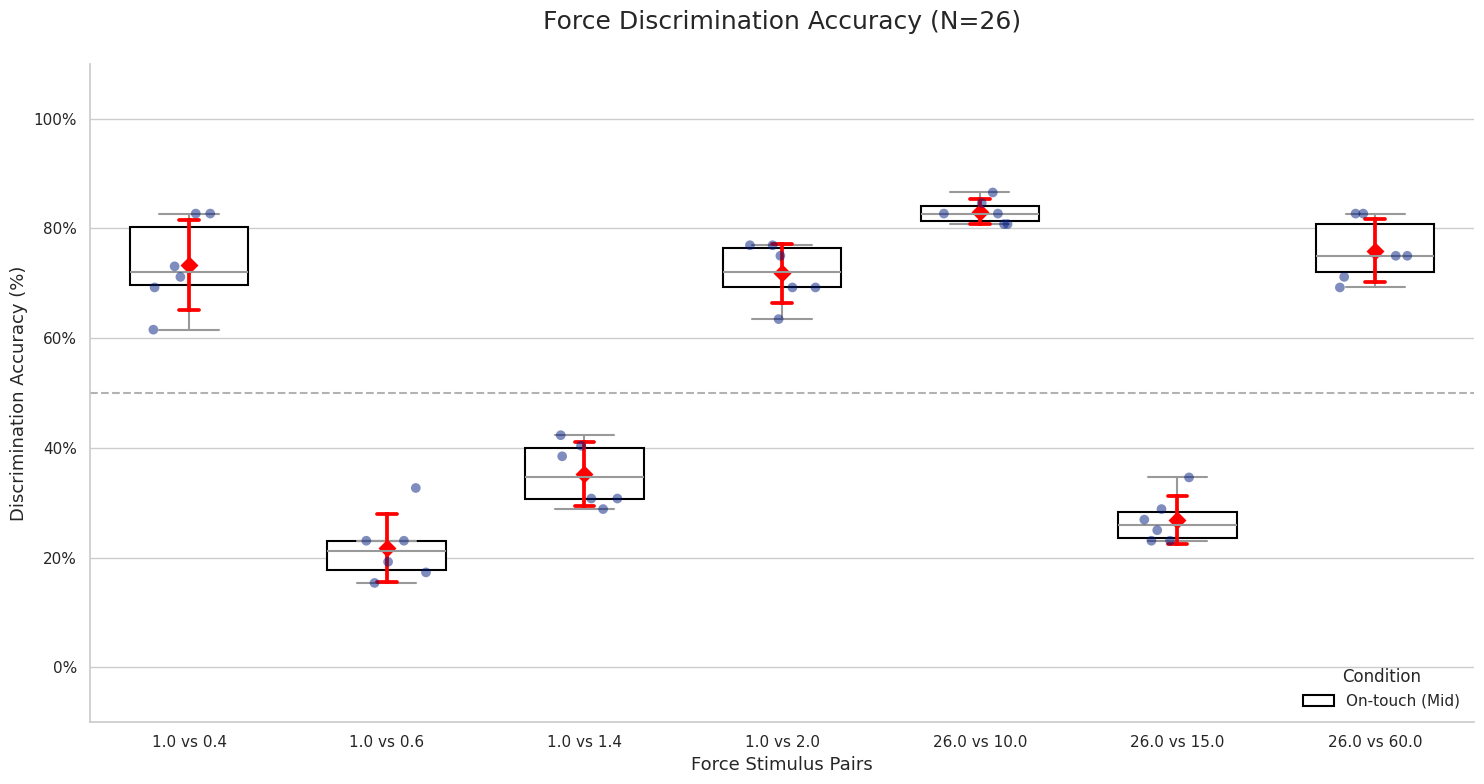

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import glob

# 1. 데이터 로드 및 통합
file_pattern = 'P*_ForceDiscrimination.csv'
file_list = glob.glob(file_pattern)

if not file_list:
    print("CSV 파일을 찾을 수 없습니다.")
else:
    print(f"발견된 파일: {file_list}")
    df_list = [pd.read_csv(f) for f in file_list]
    df_merged = pd.concat(df_list, ignore_index=True)

    # 2. 전처리 및 정답 로직
    df_merged['Ref_num'] = pd.to_numeric(df_merged['Reference'])
    df_merged['Comp_num'] = pd.to_numeric(df_merged['Comparison'])
    df_merged['Pair'] = df_merged.apply(lambda x: f"{x['Ref_num']:.1f} vs {x['Comp_num']:.1f}", axis=1)

    def calc_accuracy(row):
        if row['FirstStim'] > row['SecondStim']:
            return 1 if row['UserChoice'] == 1 else 0
        elif row['SecondStim'] > row['FirstStim']:
            return 1 if row['UserChoice'] == 2 else 0
        else:
            return 0.5

    df_merged['IsCorrect'] = df_merged.apply(calc_accuracy, axis=1)

    # 3. 분석 그룹화
    plot_df = df_merged.groupby(['Condition', 'Pair', 'Comp_num', 'Region'])['IsCorrect'].mean().reset_index()
    plot_df['Accuracy (%)'] = plot_df['IsCorrect'] * 100
    pair_order = plot_df.sort_values('Comp_num')['Pair'].unique()

    # --- [중요] 조건 개수에 따른 dodge 및 palette 설정 ---
    unique_conditions = plot_df['Condition'].unique()
    num_cond = len(unique_conditions)

    # 조건이 1개면 dodge를 False(0)로, 2개 이상이면 0.5로 설정
    dodge_val = 0.5 if num_cond > 1 else False
    # 조건 개수에 맞게 팔레트 색상 개수 조절 (경고 방지)
    base_palette = ['#FFFFFF', '#D3D3D3'][:num_cond]

    # 4. 시각화
    plt.figure(figsize=(15, 8))
    sns.set_theme(style="whitegrid")

    # [A] 박스플롯
    sns.boxplot(
        data=plot_df,
        x='Pair',
        y='Accuracy (%)',
        hue='Condition',
        order=pair_order,
        palette=base_palette,
        width=0.6,
        linewidth=1.5,
        fliersize=0,
        boxprops={'edgecolor': 'black'}
    )

    # [B] 스트립플롯 (dodge_val 적용)
    sns.stripplot(
        data=plot_df,
        x='Pair',
        y='Accuracy (%)',
        hue='Condition',
        order=pair_order,
        dodge=dodge_val,
        palette='dark',
        size=7,
        alpha=0.5,
        jitter=0.2
    )

    # [C] 에러바 (dodge_val 적용 및 FutureWarning 방지용 palette 사용)
    sns.pointplot(
        data=plot_df,
        x='Pair',
        y='Accuracy (%)',
        hue='Condition',
        order=pair_order,
        dodge=dodge_val,
        palette=['red'] * num_cond, # color='red' 대신 palette 사용
        errorbar='sd',
        markers='D',
        linestyle='none',
        capsize=.1
    )

    # 그래프 레이아웃 설정
    num_subjects = df_merged['Subject'].nunique()
    print(f"Number of Subjects: {num_subjects}")
    plt.title(f'Force Discrimination Accuracy (N={num_subjects})', fontsize=18, pad=25)
    plt.ylabel('Discrimination Accuracy (%)', fontsize=13)
    plt.xlabel('Force Stimulus Pairs', fontsize=13)

    plt.axhline(50, ls='--', color='black', alpha=0.3, label='Chance (50%)')
    plt.ylim(-10, 110)
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())

    # 범례 설정 (조건 개수만큼만 표시)
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles[:num_cond], labels[:num_cond], title='Condition', frameon=False, loc='lower right')

    sns.despine()
    plt.tight_layout()
    plt.show()

    output_filename = 'ForceDiscrimination_AggregatedData.csv'
    df.to_csv(output_filename, index=False, encoding='utf-8-sig')

    print(f"파일이 성공적으로 저장되었습니다: {output_filename}")


Subject    | Pair            | Correct  | Total  | Accuracy  
----------------------------------------------------------------------
P21        | 1.0 vs 0.4      | 6        | 12     |     50.0%
P22        | 1.0 vs 0.4      | 7        | 12     |     58.3%
P55        | 1.0 vs 0.4      | 7        | 12     |     58.3%
P23        | 1.0 vs 0.4      | 8        | 12     |     66.7%
P24        | 1.0 vs 0.4      | 8        | 12     |     66.7%
P25        | 1.0 vs 0.4      | 8        | 12     |     66.7%
P26        | 1.0 vs 0.4      | 8        | 12     |     66.7%
P27        | 1.0 vs 0.4      | 8        | 12     |     66.7%
P30        | 1.0 vs 0.4      | 8        | 12     |     66.7%
P45        | 1.0 vs 0.4      | 8        | 12     |     66.7%
P50        | 1.0 vs 0.4      | 8        | 12     |     66.7%
P51        | 1.0 vs 0.4      | 8        | 12     |     66.7%
P53        | 1.0 vs 0.4      | 8        | 12     |     66.7%
P42        | 1.0 vs 0.4      | 9        | 12     |     75.0%
P47        |

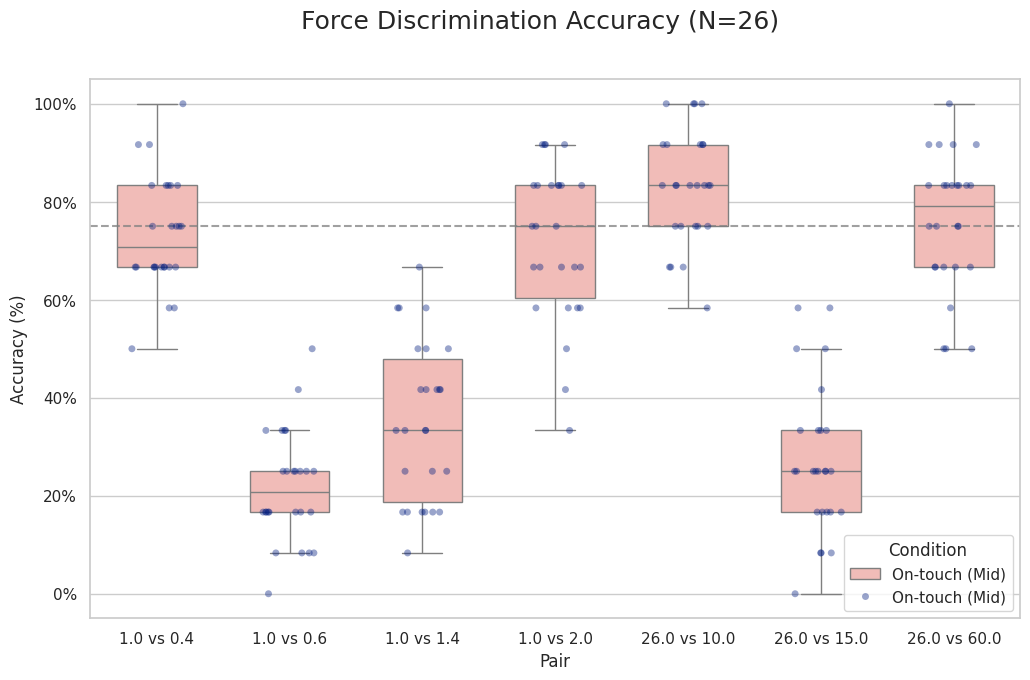

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import glob

# 1. 데이터 로드
file_pattern = 'P*_ForceDiscrimination.csv'
file_list = glob.glob(file_pattern)

if not file_list:
    print("CSV 파일을 찾을 수 없습니다.")
else:
    df_list = [pd.read_csv(f) for f in file_list]
    df_merged = pd.concat(df_list, ignore_index=True)

    # 2. 정답 여부 판별
    def calc_accuracy(row):
        if row['UserChoice'] == 1:
            return 1 if row['FirstStim'] > row['SecondStim'] else 0
        elif row['UserChoice'] == 2:
            return 1 if row['SecondStim'] > row['FirstStim'] else 0
        return 0

    df_merged['IsCorrect'] = df_merged.apply(calc_accuracy, axis=1)

    # 3. 시각화 데이터 가공 및 로깅(Logging) 준비
    df_merged['Ref_num'] = pd.to_numeric(df_merged['Reference'])
    df_merged['Comp_num'] = pd.to_numeric(df_merged['Comparison'])
    df_merged['Pair'] = df_merged.apply(lambda x: f"{x['Ref_num']:.1f} vs {x['Comp_num']:.1f}", axis=1)

    # 로깅을 위해 '맞은 개수'와 '전체 개수'를 먼저 구함
    log_df = df_merged.groupby(['Condition', 'Pair', 'Subject'])['IsCorrect'].agg(['sum', 'count']).reset_index()
    log_df['Accuracy (%)'] = (log_df['sum'] / log_df['count']) * 100

    # --- [데이터 포인트 정보 로깅 출력] ---
    print("\n" + "="*70)
    print(f"{'Subject':<10} | {'Pair':<15} | {'Correct':<8} | {'Total':<6} | {'Accuracy':<10}")
    print("-" * 70)

    # 가독성을 위해 정렬 후 출력
    for _, row in log_df.sort_values(['Pair', 'Accuracy (%)']).iterrows():
        print(f"{row['Subject']:<10} | {row['Pair']:<15} | {int(row['sum']):<8} | {int(row['count']):<6} | {row['Accuracy (%)']:>8.1f}%")
    print("="*70 + "\n")

    # 4. 시각화 (기존 코드 유지)
    num_subjects = df_merged['Subject'].nunique()
    plt.figure(figsize=(12, 7))
    sns.set_theme(style="whitegrid")

    pair_order = log_df.sort_values('Pair')['Pair'].unique()

    sns.boxplot(data=log_df, x='Pair', y='Accuracy (%)', hue='Condition', order=pair_order, palette='Pastel1', width=0.6, fliersize=0)
    sns.stripplot(data=log_df, x='Pair', y='Accuracy (%)', hue='Condition', order=pair_order, dodge=True, palette='dark', alpha=0.4, jitter=0.2)

    plt.suptitle(f'Force Discrimination Accuracy (N={num_subjects})', fontsize=18)
    plt.axhline(75, ls='--', color='gray', alpha=0.75, label='Chance (75%)')
    plt.ylim(-5, 105)
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
    plt.show()

#Bias 확인

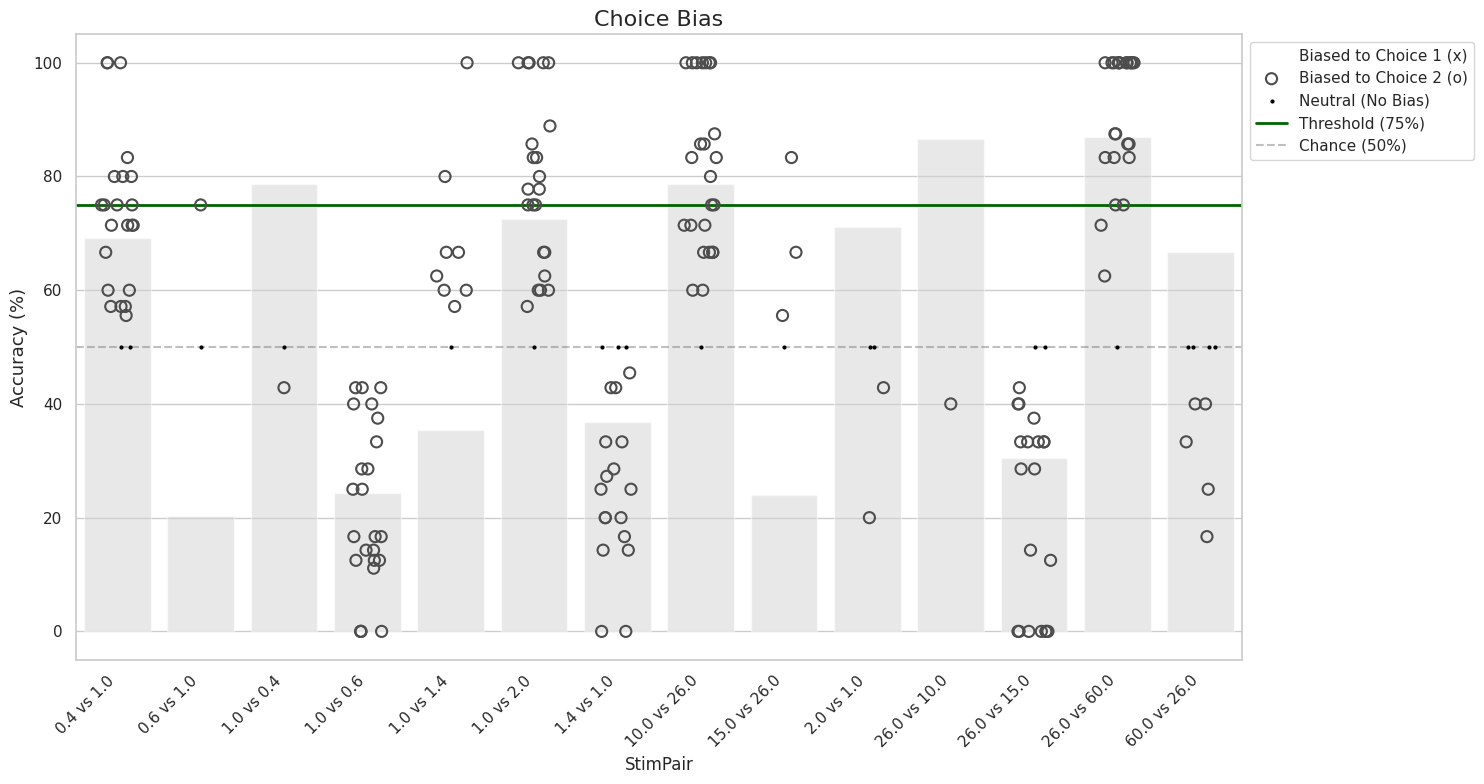

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob

# 1. 데이터 로드 및 병합
file_pattern = 'P*_ForceDiscrimination.csv'
file_list = glob.glob(file_pattern)

if not file_list:
    print("CSV 파일을 찾을 수 없습니다.")
else:
    df_list = [pd.read_csv(f) for f in file_list]
    df_merged = pd.concat(df_list, ignore_index=True)

    # 2. 정답 여부 판별 함수
    def calc_accuracy(row):
        if row['UserChoice'] == 1:
            return 1 if row['FirstStim'] > row['SecondStim'] else 0
        elif row['UserChoice'] == 2:
            return 1 if row['SecondStim'] > row['FirstStim'] else 0
        return 0

    df_merged['IsCorrect'] = df_merged.apply(calc_accuracy, axis=1)
    df_merged['StimPair'] = df_merged.apply(lambda x: f"{x['FirstStim']:.1f} vs {x['SecondStim']:.1f}", axis=1)

    # 3. 피험자별 통계 (정확도 및 선택 비율)
    sub_stats = df_merged.groupby(['Subject', 'StimPair']).agg(
        Total_Trials=('UserChoice', 'count'),
        Count_Choice1=('UserChoice', lambda x: (x == 1).sum()),
        Accuracy_Mean=('IsCorrect', 'mean')
    ).reset_index()

    sub_stats['Choice1_Ratio'] = sub_stats['Count_Choice1'] / sub_stats['Total_Trials']
    sub_stats['Accuracy_Pct'] = sub_stats['Accuracy_Mean'] * 100

    # 4. 시각화 (Y축 = Accuracy %)
    plt.figure(figsize=(15, 8))
    ax = plt.gca()

    pair_order = sorted(sub_stats['StimPair'].unique())

    # 평균 정확도 막대
    sns.barplot(data=sub_stats, x='StimPair', y='Accuracy_Pct', ax=ax,
                color='lightgray', alpha=0.5, order=pair_order, errorbar=None)

    # 선택 편향에 따라 데이터 분리하여 기호 다르게 표시
    bias_1 = sub_stats[sub_stats['Choice1_Ratio'] > 0.5]  # 1번 더 많이 선택
    bias_2 = sub_stats[sub_stats['Choice1_Ratio'] < 0.5]  # 2번 더 많이 선택
    neutral = sub_stats[sub_stats['Choice1_Ratio'] == 0.5] # 반반

    # 기호 표시 (X축: 자극쌍, Y축: 정확도)
    if not bias_1.empty:
        sns.stripplot(data=bias_1, x='StimPair', y='Accuracy_Pct', ax=ax,
                      marker='x', color='red', size=9, jitter=0.2, order=pair_order, label='Biased to Choice 1 (x)')

    if not bias_2.empty:
        sns.stripplot(data=bias_2, x='StimPair', y='Accuracy_Pct', ax=ax,
                      marker='o', color='blue', size=8, jitter=0.2, order=pair_order,
                      facecolor='none', linewidth=1.5, label='Biased to Choice 2 (o)')

    if not neutral.empty:
        sns.stripplot(data=neutral, x='StimPair', y='Accuracy_Pct', ax=ax,
                      marker='.', color='black', size=6, jitter=0.2, order=pair_order, label='Neutral (No Bias)')

    # 기준선 및 스타일 설정
    plt.axhline(75, color='darkgreen', linestyle='-', linewidth=2, label='Threshold (75%)')
    plt.axhline(50, color='gray', linestyle='--', alpha=0.5, label='Chance (50%)')

    plt.title('Choice Bias', fontsize=16)
    plt.ylabel('Accuracy (%)', fontsize=13)
    plt.ylim(-5, 105)
    plt.xticks(rotation=45, ha='right')

    # 범례 설정 (중복 항목 제거)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='upper left', bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.show()


Subject  | Magnitude Pair  | Order Condition           |   C1 %
-------------------------------------------------------------------------------------
P21      | 0.4g & 1.0g     | 1st Stronger (Correct: 1) |   42.9%
P22      | 0.4g & 1.0g     | 1st Stronger (Correct: 1) |   60.0%
P23      | 0.4g & 1.0g     | 1st Stronger (Correct: 1) |   60.0%
P24      | 0.4g & 1.0g     | 1st Stronger (Correct: 1) |   77.8%
P25      | 0.4g & 1.0g     | 1st Stronger (Correct: 1) |   71.4%
P26      | 0.4g & 1.0g     | 1st Stronger (Correct: 1) |   57.1%
P27      | 0.4g & 1.0g     | 1st Stronger (Correct: 1) |   80.0%
P28      | 0.4g & 1.0g     | 1st Stronger (Correct: 1) |  100.0%
P30      | 0.4g & 1.0g     | 1st Stronger (Correct: 1) |  100.0%
P32      | 0.4g & 1.0g     | 1st Stronger (Correct: 1) |   75.0%
P42      | 0.4g & 1.0g     | 1st Stronger (Correct: 1) |   75.0%
P44      | 0.4g & 1.0g     | 1st Stronger (Correct: 1) |   85.7%
P45      | 0.4g & 1.0g     | 1st Stronger (Correct: 1) |   50.0%
P46 

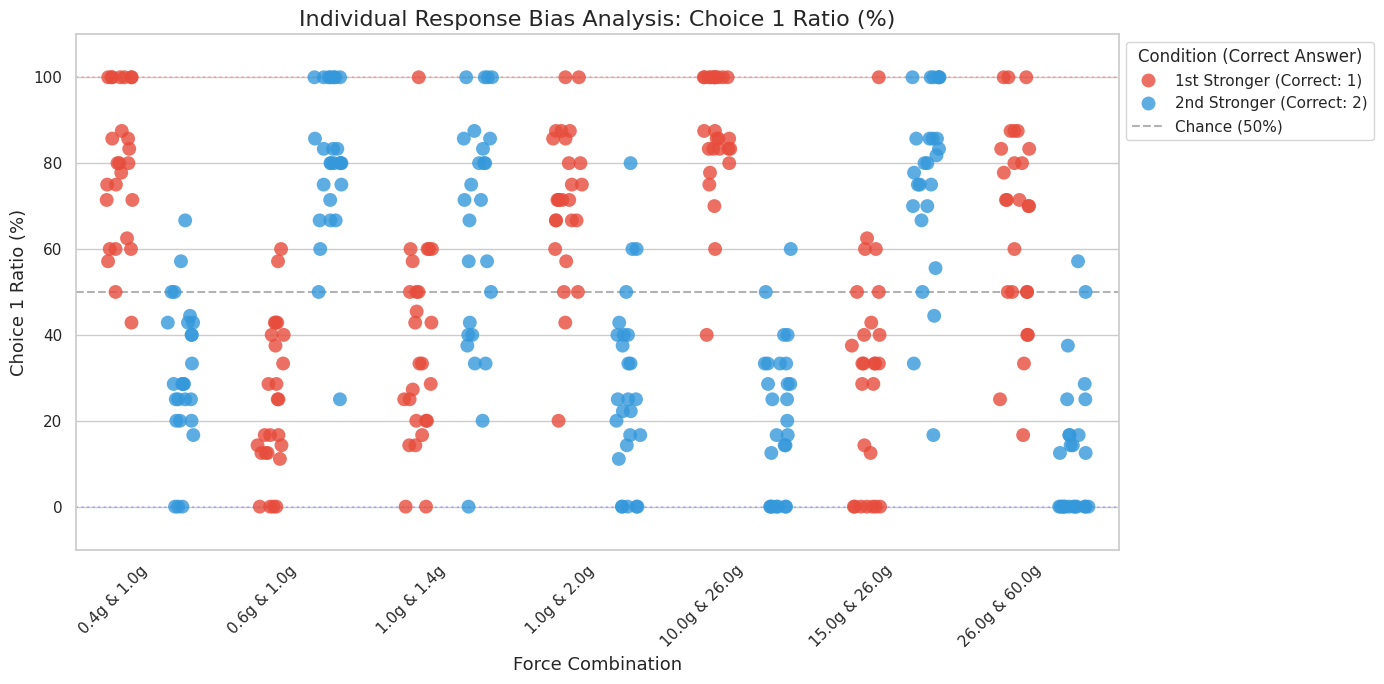

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob

# 1. 데이터 로드 및 병합
file_pattern = 'P*_ForceDiscrimination.csv'
file_list = glob.glob(file_pattern)

if not file_list:
    print("CSV 파일을 찾을 수 없습니다.")
else:
    df_list = [pd.read_csv(f) for f in file_list]
    df_merged = pd.concat(df_list, ignore_index=True)

    # 2. 분석용 컬럼 생성
    # 자극 조합 (예: 0.4g & 1.0g)
    def get_mag_pair(row):
        mags = sorted([row['FirstStim'], row['SecondStim']])
        return f"{mags[0]:.1f}g & {mags[1]:.1f}g"

    df_merged['MagPair'] = df_merged.apply(get_mag_pair, axis=1)

    # 순서 타입 정의
    def get_order_type(row):
        if row['FirstStim'] > row['SecondStim']:
            return "1st Stronger (Correct: 1)"
        else:
            return "2nd Stronger (Correct: 2)"

    df_merged['OrderType'] = df_merged.apply(get_order_type, axis=1)

    # 3. 데이터 로깅 (Logging) 준비
    # 피험자별/조합별/순서별 '1번 선택 비율' 계산
    sub_response = df_merged.groupby(['Subject', 'MagPair', 'OrderType']).agg(
        Total_Trials=('UserChoice', 'count'),
        Choice1_Count=('UserChoice', lambda x: (x == 1).sum()),
        Choice2_Count=('UserChoice', lambda x: (x == 2).sum())
    ).reset_index()

    sub_response['Choice1_Ratio_Pct'] = (sub_response['Choice1_Count'] / sub_response['Total_Trials']) * 100

    # --- [콘솔 로그 출력 시작] ---
    print("\n" + "="*85)
    print(f"{'Subject':<8} | {'Magnitude Pair':<15} | {'Order Condition':<25} | {'C1 %':>6}")
    print("-" * 85)

    log_sorted = sub_response.sort_values(['MagPair', 'OrderType', 'Subject'])
    for _, row in log_sorted.iterrows():
        print(f"{row['Subject']:<8} | {row['MagPair']:<15} | {row['OrderType']:<25} | {row['Choice1_Ratio_Pct']:>6.1f}%")
    print("="*85 + "\n")
    # --- [콘솔 로그 출력 끝] ---

    # CSV 파일로 저장
    sub_response.to_csv('subject_choice_logging.csv', index=False)
    print(f"상세 로그가 'subject_choice_logging.csv'로 저장되었습니다.")

    # 4. 시각화 (Scatter/Strip Plot)
    plt.figure(figsize=(14, 7))
    mag_order = sorted(sub_response['MagPair'].unique())

    sns.stripplot(
        data=sub_response,
        x='MagPair',
        y='Choice1_Ratio_Pct',
        hue='OrderType',
        dodge=True,
        palette={'1st Stronger (Correct: 1)': '#e74c3c', '2nd Stronger (Correct: 2)': '#3498db'},
        jitter=0.2,
        size=10,
        alpha=0.8,
        order=mag_order
    )

    # 기준선 및 스타일
    plt.axhline(50, color='black', linestyle='--', alpha=0.3, label='Chance (50%)')
    plt.axhline(100, color='red', linestyle=':', alpha=0.2)
    plt.axhline(0, color='blue', linestyle=':', alpha=0.2)

    plt.title('Individual Response Bias Analysis: Choice 1 Ratio (%)', fontsize=16)
    plt.ylabel('Choice 1 Ratio (%)', fontsize=13)
    plt.xlabel('Force Combination', fontsize=13)
    plt.ylim(-10, 110)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Condition (Correct Answer)', loc='upper left', bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_3138/1393808776.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], data=plot_data, x='Pair', y='Accuracy (%)', order=pair_order, palette='Set3', width=0.5, fliersize=0)
/tmp/ipykernel_3138/1393808776.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], data=plot_data, x='Pair', y='Accuracy (%)', order=pair_order, palette='Set3', width=0.5, fliersize=0)


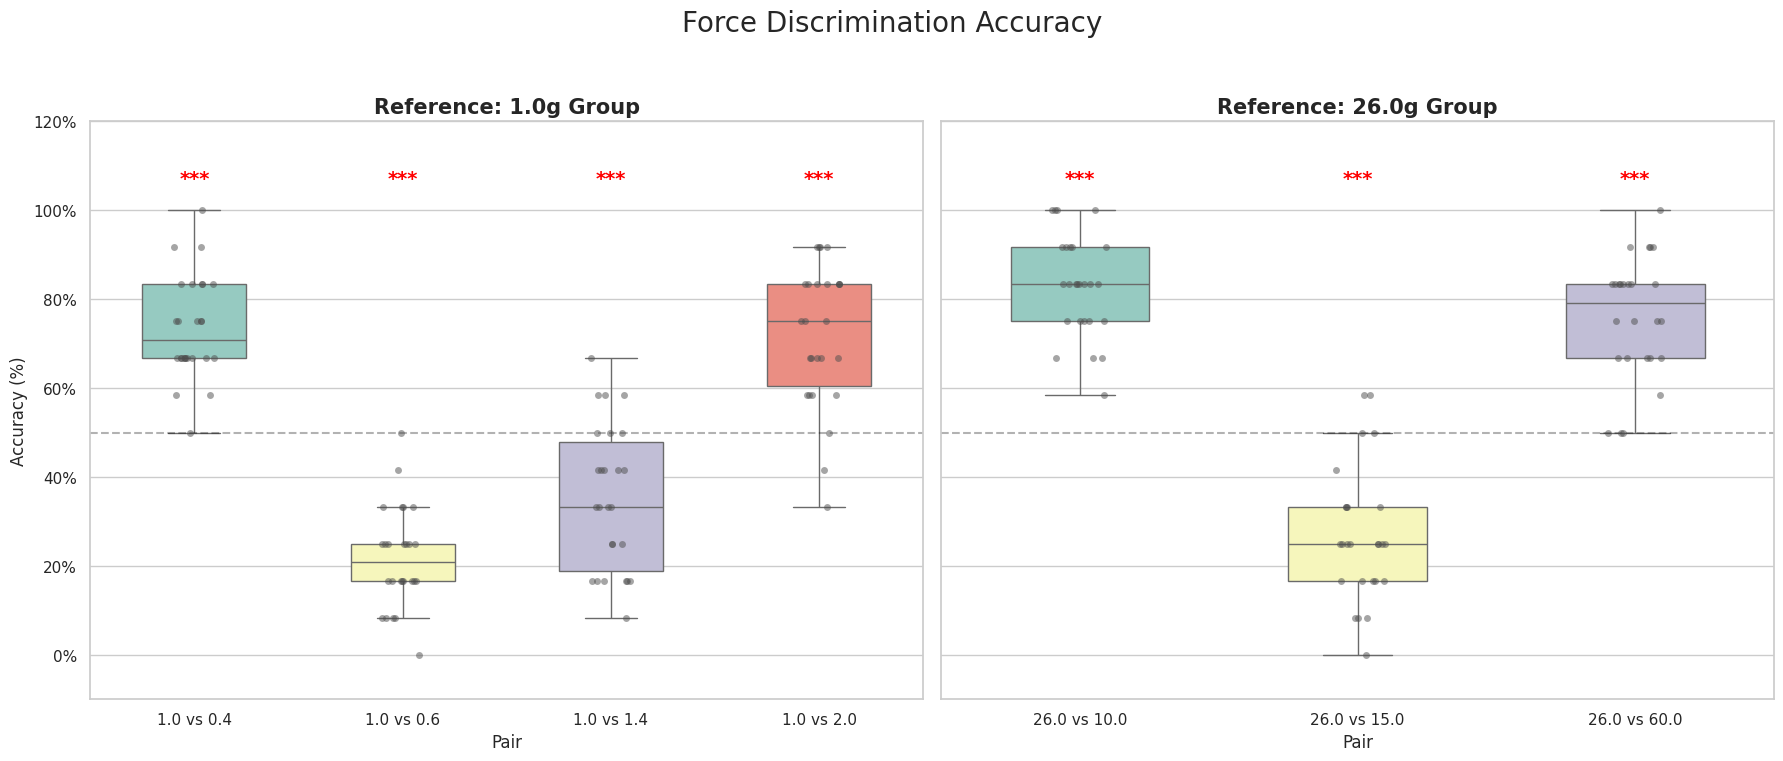


[GLMM Report for 1.0g]
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 1.0149      0.114      8.920      0.000       0.792       1.238
C(Pair)[T.1.0 vs 0.6]    -2.2925      0.175    -13.138      0.000      -2.635      -1.951
C(Pair)[T.1.0 vs 1.4]    -1.6227      0.164     -9.890      0.000      -1.944      -1.301
C(Pair)[T.1.0 vs 2.0]    -0.0806      0.160     -0.503      0.615      -0.394       0.233

[GLMM Report for 26.0g]
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   1.5865      0.156     10.186      0.000       1.281       1.892
C(Pair)[T.26.0 vs 15.0]    -2.5851      0.225    -11.508      0.000      -3.025      -2.145
C(Pair)[T.26.0 vs 60.0]    -0.4360      0.2

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import glob
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import ttest_1samp

# 1. 데이터 로드 및 전처리
file_pattern = 'P*_ForceDiscrimination.csv'
file_list = glob.glob(file_pattern)

if not file_list:
    print("CSV 파일을 찾을 수 없습니다.")
else:
    df_list = [pd.read_csv(f) for f in file_list]
    df_merged = pd.concat(df_list, ignore_index=True)

    def calc_accuracy(row):
        if row['UserChoice'] == 1:
            return 1 if row['FirstStim'] > row['SecondStim'] else 0
        elif row['UserChoice'] == 2:
            return 1 if row['SecondStim'] > row['FirstStim'] else 0
        return 0

    df_merged['IsCorrect'] = df_merged.apply(calc_accuracy, axis=1)
    df_merged['Ref_num'] = pd.to_numeric(df_merged['Reference'])
    df_merged['Pair'] = df_merged.apply(lambda x: f"{float(x['Reference']):.1f} vs {float(x['Comparison']):.1f}", axis=1)

    # 별 개수 결정 함수
    def get_stars(p_val):
        if p_val < 0.001: return '***'
        elif p_val < 0.01: return '**'
        elif p_val < 0.05: return '*'
        return 'n.s.'

    # 시각화 설정
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
    ref_values = [1.0, 26.0]

    for i, ref in enumerate(ref_values):
        sub_df = df_merged[df_merged['Ref_num'] == ref].copy()
        plot_data = sub_df.groupby(['Pair', 'Subject'])['IsCorrect'].mean().reset_index()
        plot_data['Accuracy (%)'] = plot_data['IsCorrect'] * 100

        pair_order = sorted(sub_df['Pair'].unique())

        # Boxplot & Stripplot
        sns.boxplot(ax=axes[i], data=plot_data, x='Pair', y='Accuracy (%)', order=pair_order, palette='Set3', width=0.5, fliersize=0)
        sns.stripplot(ax=axes[i], data=plot_data, x='Pair', y='Accuracy (%)', order=pair_order, color='.3', alpha=0.5)

        # --- 통계 및 별점 추가 부분 ---
        for j, pair in enumerate(pair_order):
            pair_values = plot_data[plot_data['Pair'] == pair]['Accuracy (%)']
            # One-sample t-test (50% 기준보다 유의미하게 높은지 확인)
            t_stat, p_val = ttest_1samp(pair_values, 50)

            # 별표 표시
            stars = get_stars(p_val)
            if stars != 'n.s.':
                # 박스플롯 위쪽에 별 표시
                y_max = plot_data['Accuracy (%)'].max()
                axes[i].text(j, y_max + 5, stars, ha='center', va='bottom', color='red', fontsize=14, fontweight='bold')

        axes[i].set_title(f'Reference: {ref}g Group', fontsize=15, fontweight='bold')
        axes[i].axhline(50, ls='--', color='black', alpha=0.3)
        axes[i].set_ylim(-10, 120)
        axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())

    plt.suptitle('Force Discrimination Accuracy', fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # GLMM 상세 리포트 출력 (기존 GEE 방식 유지)
    for ref in ref_values:
        subset = df_merged[df_merged['Ref_num'] == ref]
        model = smf.gee("IsCorrect ~ C(Pair)", data=subset, groups=subset["Subject"], family=sm.families.Binomial())
        result = model.fit()
        print(f"\n[GLMM Report for {ref}g]")
        print(result.summary().tables[1])

/tmp/ipykernel_3138/2147018344.py:78: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_3138/2147018344.py:78: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_3138/2147018344.py:78: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_3138/2147018344.py:78: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` pa

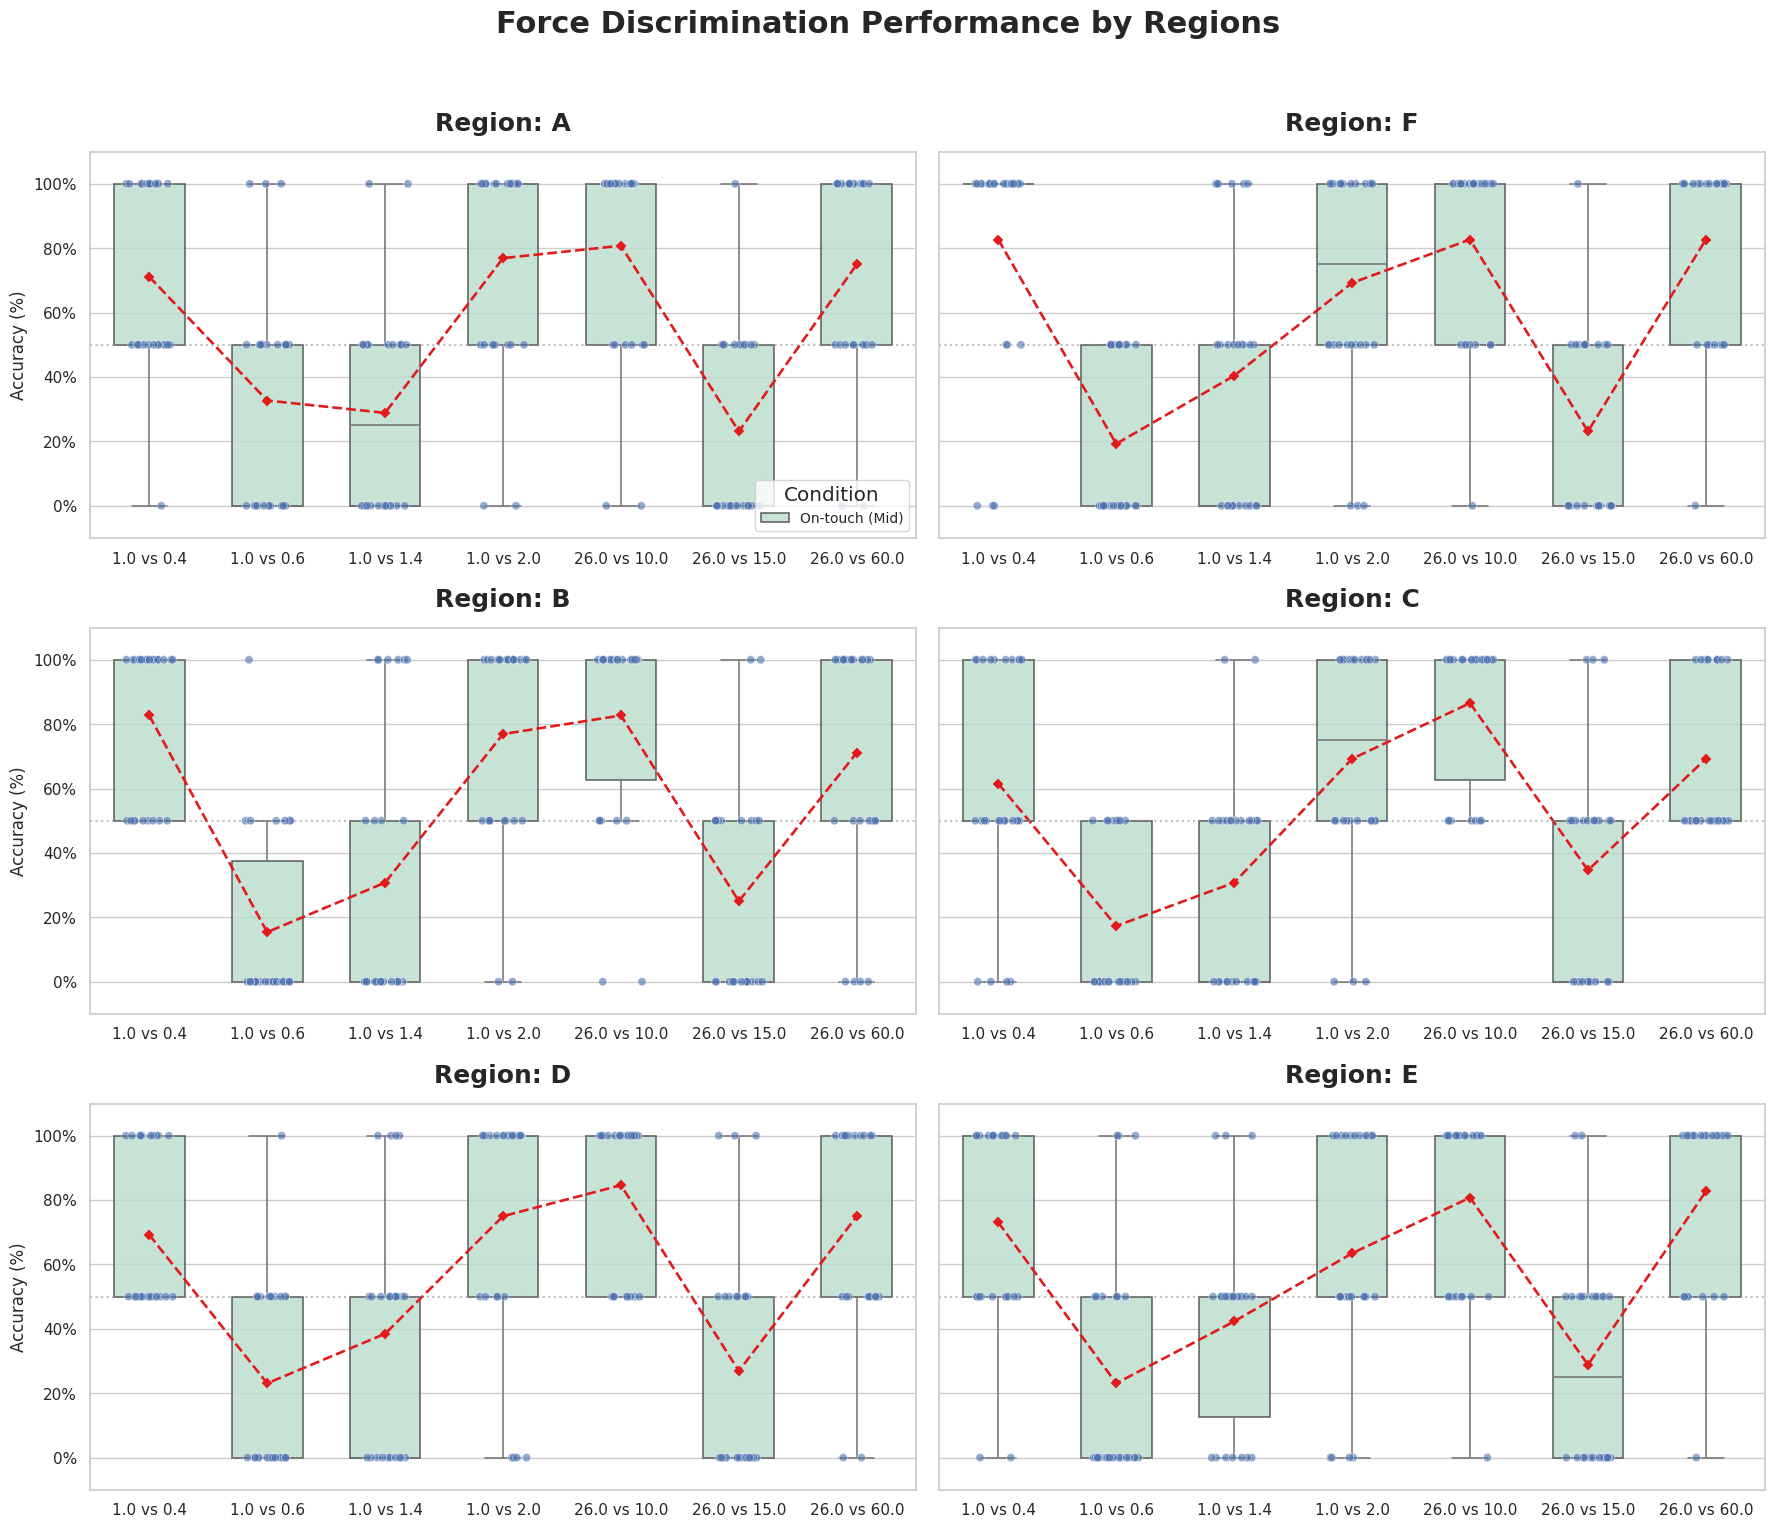


[Data Points Summary for Scatter Plot]
Pair                   1.0 vs 0.4  1.0 vs 0.6  1.0 vs 1.4  1.0 vs 2.0  \
Region Condition                                                        
A      On-touch (Mid)          26          26          26          26   
B      On-touch (Mid)          26          26          26          26   
C      On-touch (Mid)          26          26          26          26   
D      On-touch (Mid)          26          26          26          26   
E      On-touch (Mid)          26          26          26          26   
F      On-touch (Mid)          26          26          26          26   

Pair                   26.0 vs 10.0  26.0 vs 15.0  26.0 vs 60.0  
Region Condition                                                 
A      On-touch (Mid)            26            26            26  
B      On-touch (Mid)            26            26            26  
C      On-touch (Mid)            26            26            26  
D      On-touch (Mid)            26          

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import glob

# 1. 데이터 로드 및 통합
file_pattern = 'P*_ForceDiscrimination.csv'
file_list = glob.glob(file_pattern)

if not file_list:
    print("CSV 파일을 찾을 수 없습니다.")
else:
    df_list = [pd.read_csv(f) for f in file_list]
    df_merged = pd.concat(df_list, ignore_index=True)

    # 2. 전처리 및 정답 로직
    df_merged['Ref_num'] = pd.to_numeric(df_merged['Reference'])
    df_merged['Comp_num'] = pd.to_numeric(df_merged['Comparison'])
    df_merged['Pair'] = df_merged.apply(lambda x: f"{x['Ref_num']:.1f} vs {x['Comp_num']:.1f}", axis=1)

    def calc_accuracy(row):
        if row['FirstStim'] > row['SecondStim']:
            return 1 if row['UserChoice'] == 1 else 0
        elif row['SecondStim'] > row['FirstStim']:
            return 1 if row['UserChoice'] == 2 else 0
        else:
            return 0.5
    df_merged['IsCorrect'] = df_merged.apply(calc_accuracy, axis=1)

    # 3. 분석 그룹화 (Subject 포함하여 25개 내외의 점 생성)
    plot_df = df_merged.groupby(['Condition', 'Pair', 'Comp_num', 'Region', 'Subject'])['IsCorrect'].mean().reset_index()
    plot_df['Accuracy (%)'] = plot_df['IsCorrect'] * 100

    pair_order = plot_df.sort_values('Comp_num')['Pair'].unique()

    # --- 수정된 부분: 출력 순서를 A, F, B, C, D, E 순으로 설정 ---
    custom_order = ['A', 'F', 'B', 'C', 'D', 'E']
    existing_regions = plot_df['Region'].unique()
    # 데이터에 존재하는 Region만 필터링하되 요청하신 순서를 유지
    regions = [r for r in custom_order if r in existing_regions]
    # -------------------------------------------------------

    # 4. 시각화 (디자인 강화 버전)
    n_rows = (len(regions) + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(18, 5 * n_rows), sharey=True)
    axes = axes.flatten()

    # 테마 설정
    sns.set_theme(style="whitegrid", font_scale=1.2)

    # 세련된 컬러 팔레트 설정
    box_palette = "Pastel2"  # 부드러운 파스텔 톤
    dot_palette = "deep"     # 선명한 점 컬러

    for i, reg in enumerate(regions):
        reg_data = plot_df[plot_df['Region'] == reg]
        ax = axes[i]

        num_cond = reg_data['Condition'].nunique()
        dodge_val = 0.4 if num_cond > 1 else False

        # [A] 박스플롯: 테두리와 내부 색상 조절
        sns.boxplot(
            ax=ax, data=reg_data, x='Pair', y='Accuracy (%)', hue='Condition',
            order=pair_order, palette=box_palette, width=0.6, linewidth=1.2,
            fliersize=0, boxprops={'edgecolor': '#444444', 'alpha': 0.8}
        )

        # [B] 스트립플롯: 점들의 가독성 향상
        sns.stripplot(
            ax=ax, data=reg_data, x='Pair', y='Accuracy (%)', hue='Condition',
            order=pair_order, dodge=dodge_val, palette=dot_palette,
            size=6, alpha=0.6, jitter=0.2, linewidth=0.5, edgecolor='white'
        )

        # [C] 포인트플롯: 평균 추세선 (세련된 다크 레드/그레이 조합)
        sns.pointplot(
            ax=ax, data=reg_data, x='Pair', y='Accuracy (%)', hue='Condition',
            order=pair_order, dodge=dodge_val, palette=['#E31A1C', '#333333'][:num_cond],
            markers='D', linestyles='--', errorbar=None, scale=0.7
        )

        # 개별 그래프 디테일
        ax.set_title(f'Region: {reg}', fontsize=18, fontweight='bold', pad=15)
        ax.set_xlabel('') # 하단 라벨 생략하여 깔끔하게
        ax.set_ylabel('Accuracy (%)' if i % 2 == 0 else '')
        ax.set_ylim(-10, 110)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())

        # 50% 가이드라인
        ax.axhline(50, ls=':', color='gray', alpha=0.5, linewidth=1.5)

        # 범례 정리
        if i == 0:
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(handles[:num_cond], labels[:num_cond], title='Condition',
                      frameon=True, loc='lower right', fontsize=10)
        else:
            if ax.get_legend(): ax.get_legend().remove()

    # 빈 서브플롯 정리
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('Force Discrimination Performance by Regions', fontsize=22, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # 데이터 포인트 로깅 (실제로 찍힌 점들의 리스트)
    print("\n[Data Points Summary for Scatter Plot]")
    print(plot_df.groupby(['Region', 'Condition', 'Pair']).size().unstack(fill_value=0))

#각 force pair 별로 region 별 차이가 있는지 확인

/tmp/ipykernel_3138/829189061.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3138/829189061.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


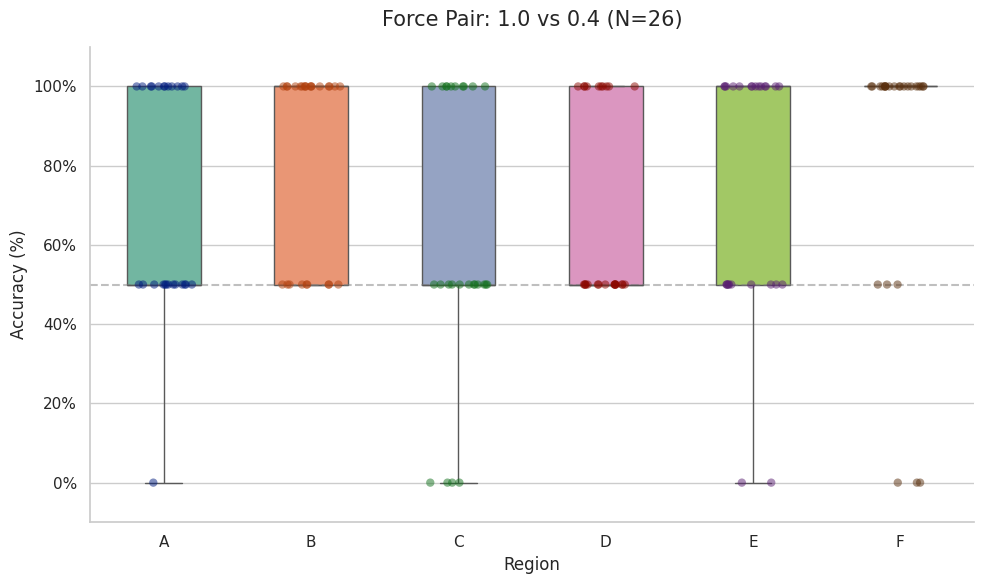

/tmp/ipykernel_3138/829189061.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3138/829189061.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


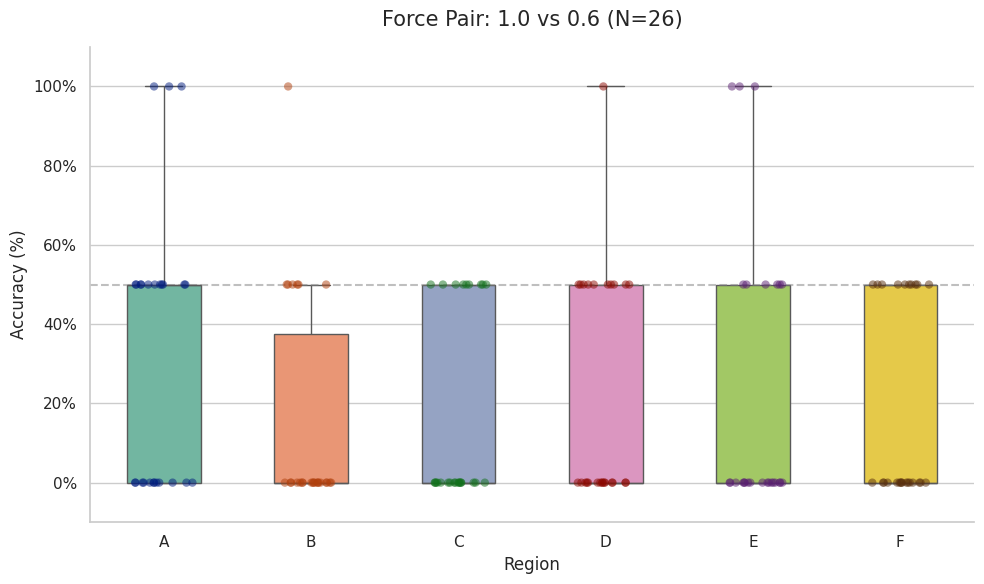

/tmp/ipykernel_3138/829189061.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3138/829189061.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


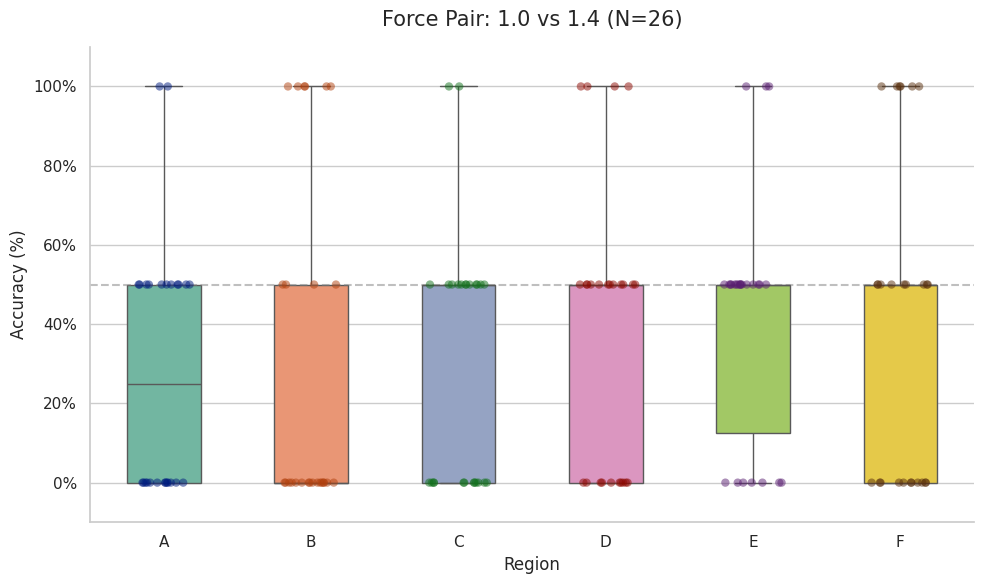

/tmp/ipykernel_3138/829189061.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3138/829189061.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


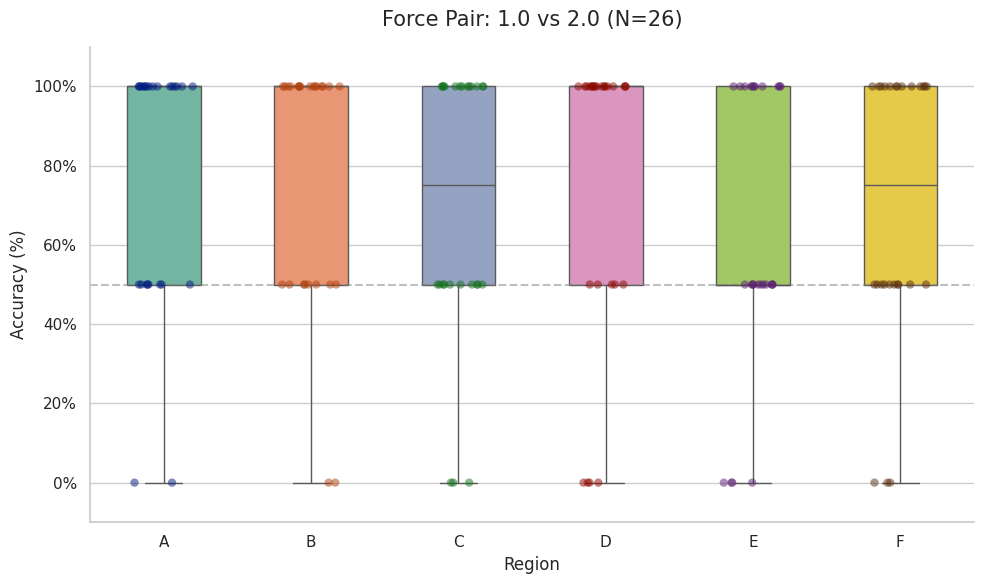

/tmp/ipykernel_3138/829189061.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3138/829189061.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


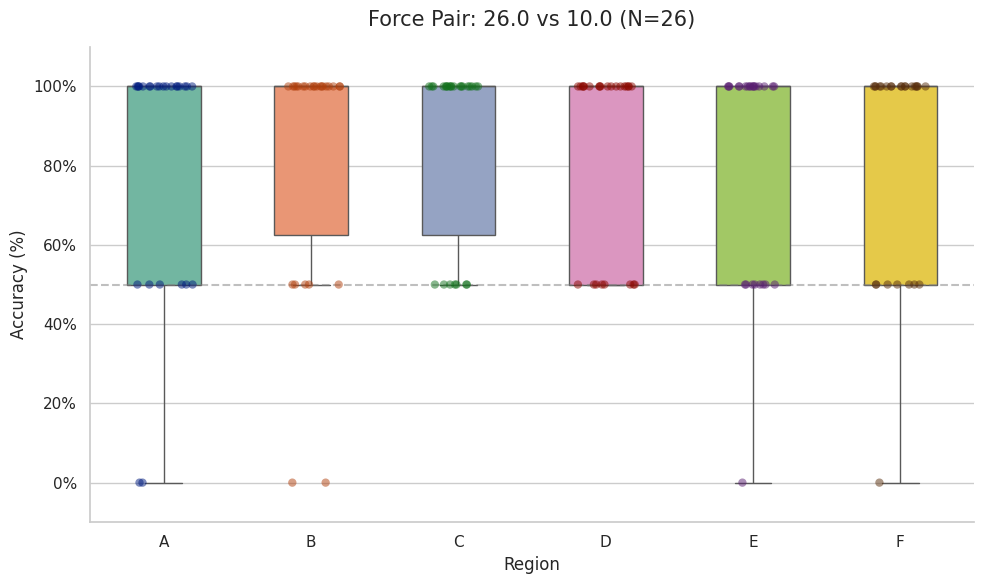

/tmp/ipykernel_3138/829189061.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3138/829189061.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


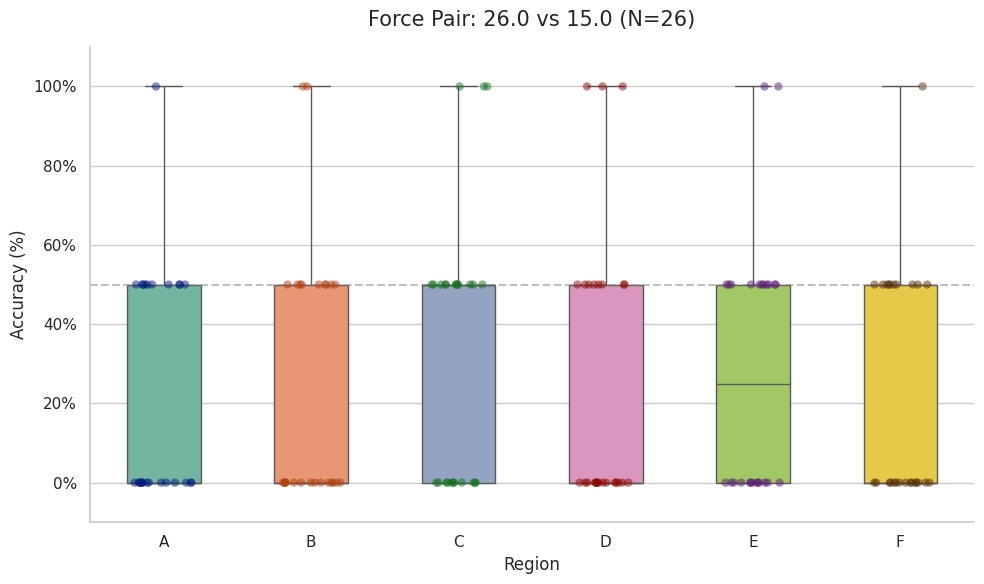

/tmp/ipykernel_3138/829189061.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3138/829189061.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


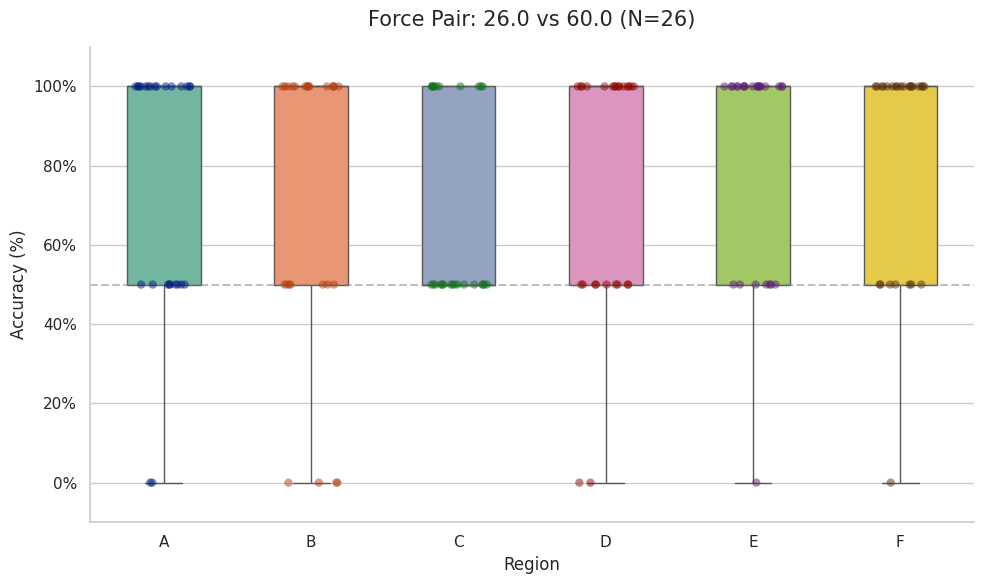

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import glob

# 1. 데이터 로드 및 통합
file_pattern = 'P*_ForceDiscrimination.csv'
file_list = glob.glob(file_pattern)

if not file_list:
    print("CSV 파일을 찾을 수 없습니다.")
else:
    df_list = [pd.read_csv(f) for f in file_list]
    df_merged = pd.concat(df_list, ignore_index=True)

    # 2. 정답 여부 판별
    def calc_accuracy(row):
        if row['UserChoice'] == 1:
            return 1 if row['FirstStim'] > row['SecondStim'] else 0
        elif row['UserChoice'] == 2:
            return 1 if row['SecondStim'] > row['FirstStim'] else 0
        return 0

    df_merged['IsCorrect'] = df_merged.apply(calc_accuracy, axis=1)

    # 3. 데이터 가공
    df_merged['Ref_num'] = pd.to_numeric(df_merged['Reference'])
    df_merged['Comp_num'] = pd.to_numeric(df_merged['Comparison'])
    df_merged['Pair'] = df_merged.apply(lambda x: f"{x['Ref_num']:.1f} vs {x['Comp_num']:.1f}", axis=1)

    # Region별 차이를 보기 위해 그룹화
    plot_df = df_merged.groupby(['Pair', 'Comp_num', 'Region', 'Subject'])['IsCorrect'].mean().reset_index()
    plot_df['Accuracy (%)'] = plot_df['IsCorrect'] * 100

    # 정렬 및 Pair 목록 추출
    region_order = sorted(plot_df['Region'].unique())
    unique_pairs = plot_df.sort_values('Comp_num')['Pair'].unique()

    # 4. 시각화: 각 Force Pair마다 개별 Figure 생성
    for target_pair in unique_pairs:
        # 해당 Pair 데이터만 필터링
        subset = plot_df[plot_df['Pair'] == target_pair]

        plt.figure(figsize=(10, 6))
        sns.set_theme(style="whitegrid")

        # [A] Boxplot: X축은 Region
        sns.boxplot(
            data=subset, x='Region', y='Accuracy (%)',
            order=region_order, palette='Set2', width=0.5, fliersize=0
        )

        # [B] Stripplot: 개별 피험자 데이터 점
        sns.stripplot(
            data=subset, x='Region', y='Accuracy (%)',
            order=region_order, palette='dark', alpha=0.5, jitter=0.2, size=6
        )

        # 그래프 레이아웃 설정
        num_subjects = subset['Subject'].nunique()
        plt.title(f'Force Pair: {target_pair} (N={num_subjects})', fontsize=15, pad=15)
        plt.ylabel('Accuracy (%)', fontsize=12)
        plt.xlabel('Region', fontsize=12)

        # 50% 기준선
        plt.axhline(50, ls='--', color='gray', alpha=0.5)
        plt.ylim(-10, 110)
        plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())

        sns.despine()
        plt.tight_layout()
        plt.show() # 각 Pair마다 그래프를 하나씩 출력